In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Tải dữ liệu
df = pd.read_excel('Online Retail.xlsx')
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom


<class 'pandas.DataFrame'>
Index: 530104 entries, 0 to 541908
Data columns (total 9 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   InvoiceNo    530104 non-null  object        
 1   StockCode    530104 non-null  object        
 2   Description  530104 non-null  object        
 3   Quantity     530104 non-null  int64         
 4   InvoiceDate  530104 non-null  datetime64[us]
 5   UnitPrice    530104 non-null  float64       
 6   CustomerID   397884 non-null  float64       
 7   Country      530104 non-null  str           
 8   TotalSales   530104 non-null  float64       
dtypes: datetime64[us](1), float64(3), int64(1), object(3), str(1)
memory usage: 40.4+ MB
None
InvoiceNo           0
StockCode           0
Description         0
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     132220
Country             0
TotalSales          0
dtype: int64


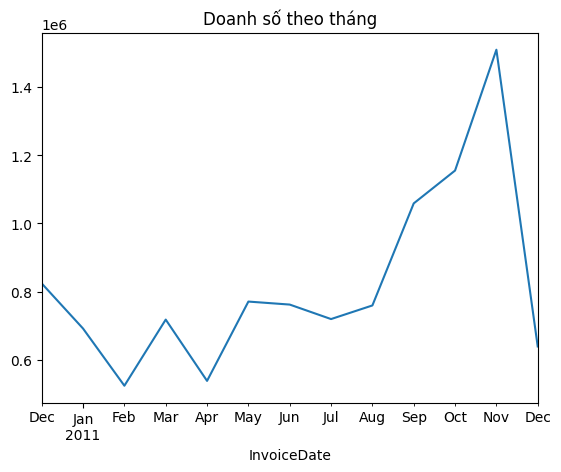

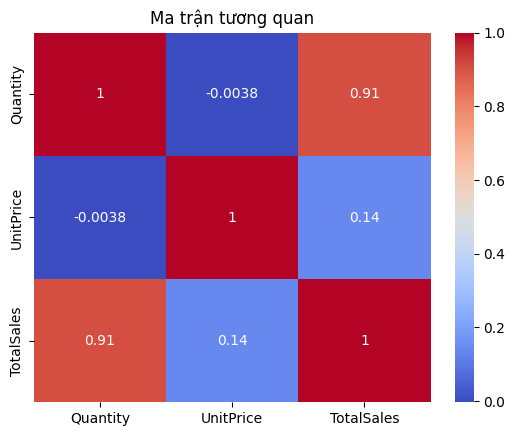

In [6]:
# 1. Kiểm tra thông tin tổng quát và dữ liệu thiếu
print(df.info())
print(df.isnull().sum())

# 2. Tạo cột Doanh số (Target Variable)
# Loại bỏ các đơn hàng có số lượng hoặc đơn giá âm (hàng trả lại)
df = df[(df['Quantity'] > 0) & (df['UnitPrice'] > 0)]
df['TotalSales'] = df['Quantity'] * df['UnitPrice'] # 

# 3. Trực quan hóa xu hướng theo thời gian
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])
df.resample('ME', on='InvoiceDate')['TotalSales'].sum().plot(kind='line', title='Doanh số theo tháng')
plt.show()

# 4. Kiểm tra tương quan giữa các biến số
sns.heatmap(df[['Quantity', 'UnitPrice', 'TotalSales']].corr(), annot=True, cmap='coolwarm')
plt.title('Ma trận tương quan')
plt.show()

In [7]:
# Trích xuất các đặc trưng thời gian (Seasonal trends) [cite: 17]
df['Month'] = df['InvoiceDate'].dt.month
df['DayOfWeek'] = df['InvoiceDate'].dt.dayofweek
df['Hour'] = df['InvoiceDate'].dt.hour

# Gom nhóm dữ liệu theo Sản phẩm và Tháng để dự báo doanh số hàng tháng
product_sales = df.groupby(['StockCode', 'Month', 'UnitPrice']).agg({
    'TotalSales': 'sum',
    'Quantity': 'sum'
}).reset_index()

# Chuyển đổi biến phân loại (StockCode) thành dạng số [cite: 10]
product_sales['StockCode_Factorized'] = pd.factorize(product_sales['StockCode'])[0]

# Chọn các đặc trưng (Features) và mục tiêu (Target)
X = product_sales[['StockCode_Factorized', 'Month', 'UnitPrice']]
y = product_sales['TotalSales'] #

In [8]:
# Chia tập train và test (80/20) [cite: 12]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Khởi tạo và huấn luyện mô hình [cite: 19, 22, 23]
rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

print("Mô hình đã được huấn luyện thành công!")

Mô hình đã được huấn luyện thành công!


In [9]:
# Dự đoán trên tập test
y_pred = rf_model.predict(X_test)

# Tính toán các chỉ số đánh giá 
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print(f"Mean Absolute Error (MAE): {mae:.2f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.2f}")
print(f"R-squared Score: {r2:.2f}")

# Xem mức độ quan trọng của các đặc trưng
features = X.columns
importances = rf_model.feature_importances_
feature_imp_df = pd.DataFrame({'Feature': features, 'Importance': importances}).sort_values(by='Importance', ascending=False)
print("\nMức độ quan trọng của các yếu tố:")
print(feature_imp_df)

Mean Absolute Error (MAE): 94.96
Root Mean Squared Error (RMSE): 1464.73
R-squared Score: 0.04

Mức độ quan trọng của các yếu tố:
                Feature  Importance
2             UnitPrice    0.387992
0  StockCode_Factorized    0.356855
1                 Month    0.255153
